In [39]:
import sys
import optuna
import pandas as pd
from dotenv import load_dotenv
from utils import analyze_strategies

sys.path.append("..")
from models.feature_engineering import get_mask, round_to_step, get_return, add_week_column
from models.etl_pipeline_local import get_over_15_table, get_win_1x_table

load_dotenv()

True

In [40]:
strategy_dict = dict()

# 1. Over 1.5

In [63]:
target_col = "over_15"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/greedy_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 2.428976876168547 {'underOver_chance_over15_use_min': True, 'underOver_chance_over15_use_max': True, 'underOver_chance_over15_min': 60, 'underOver_chance_over15_max': 90, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'underOver_comparison_affini_min': 3000, 'underOver_comparison_affini_max': 16000, 'underOver_comparison_flashback_use_min': False, 'underOver_comparison_flashback_use_max': True, 'underOver_comparison_flashback_min': 6000, 'underOver_comparison_flashback_max': 15000, 'underOver_flashback_over15_include_missing': False, 'underOver_flashback_over15_use_min': True, 'underOver_flashback_over15_use_max': False, 'underOver_flashback_over15_min': 76, 'underOver_flashback_over15_max': 92, 'evaluation_valUnderOver_cat_idx': 47}


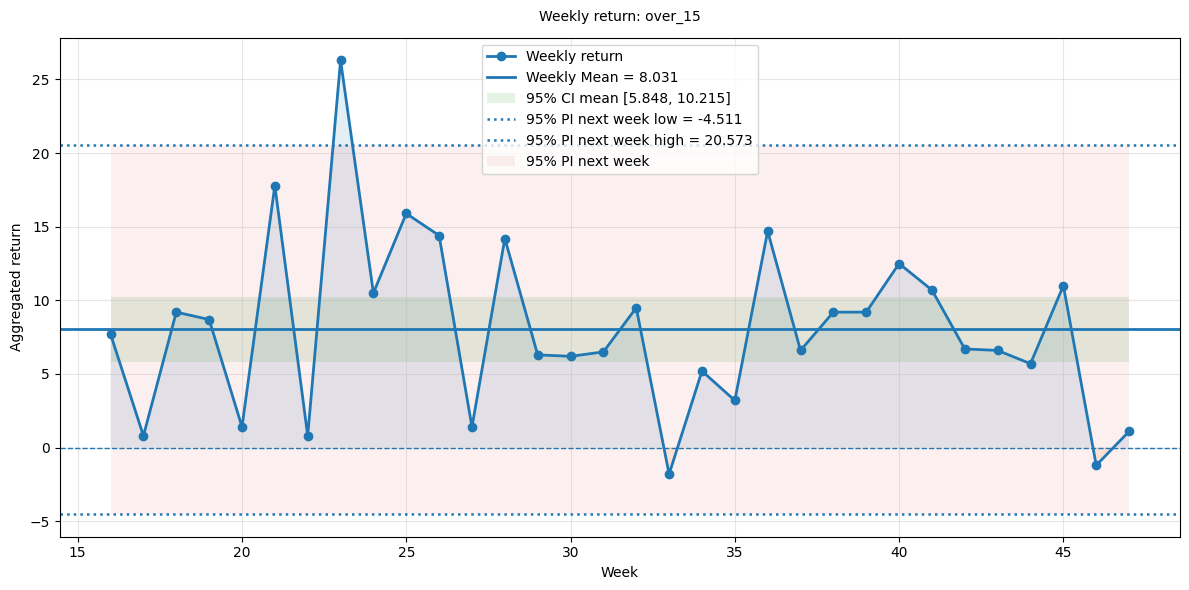

In [70]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]
# Bet setup
target_col = "over_15"
odds_col: str = "over_15_odds"

# Load data
df_loaded = get_over_15_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df[odds_col] = 1.3
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

strategy_dict[target_col] = {"df_filtered": df_filtered, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}
weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)

# 2. DNB 1

In [43]:
target_col = "dnb_1"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/greedy_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 0.155853374199445 {'chance1x2_chance_p1_use_min': False, 'chance1x2_chance_p1_use_max': True, 'chance1x2_chance_p1_min': 10, 'chance1x2_chance_p1_max': 60, 'chance1x2_bookkeeping_status_cat_idx': 4, 'chance1x2_comparison_affini_use_min': True, 'chance1x2_comparison_affini_use_max': False, 'chance1x2_comparison_affini_min': 500, 'chance1x2_comparison_affini_max': 1000, 'chance1x2_comparison_flashback_use_min': False, 'chance1x2_comparison_flashback_use_max': True, 'chance1x2_comparison_flashback_min': 9750, 'chance1x2_comparison_flashback_max': 18500, 'chance1x2_flashback_p1_include_missing': False, 'chance1x2_flashback_p1_use_min': True, 'chance1x2_flashback_p1_use_max': False, 'chance1x2_flashback_p1_min': 40, 'chance1x2_flashback_p1_max': 50, 'evaluation_val1x2_cat_idx': 90, 'evaluation_valMetrica_cat_idx': 263, 'evaluation_valScala_cat_idx': 8}


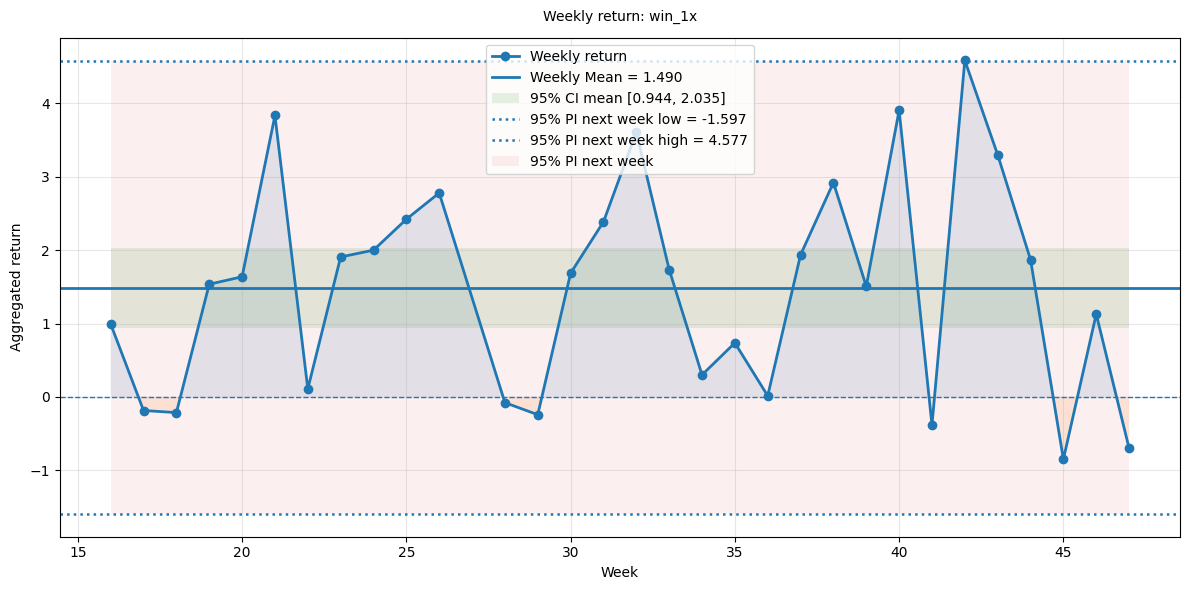

In [ ]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_1x"
odds_col: str = "dnb_1_odds"

# Load data
df_loaded = get_win_1x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
def scale_odd(quota_orig):
    return (3/7) * quota_orig + 0.4857142857

# Feature Engineering
df[odds_col] = [scale_odd(x) for x in df['chance1x2_quote_current1']]


df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df["chance1x2_quote_current1"] >= 1.9) & (df["chance1x2_quote_current1"] <= 2.6)]

df["strategy"] = target_col

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "weekly_return": , "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

# Forecast

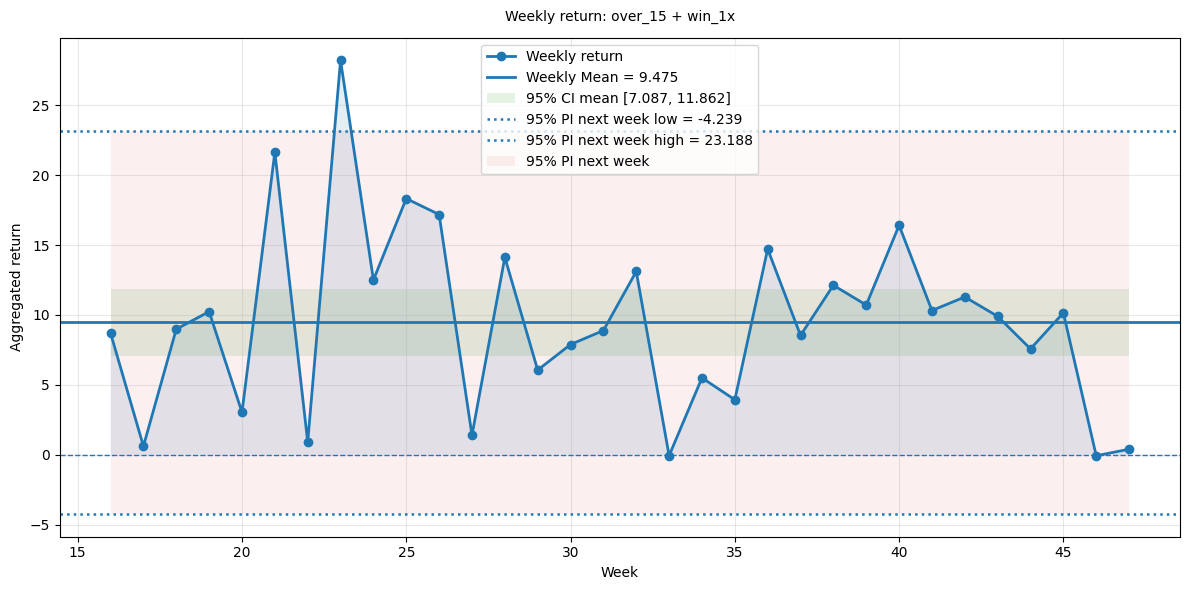

In [76]:
for i, key in enumerate(strategy_dict.keys()):
    if i == 0:
        df_final = strategy_dict[key]['df_filtered']
    else:
        df_item = strategy_dict[key]['df_filtered']
        df_final = pd.concat([df_final, df_item], axis=0)

df_final = df_final.reset_index(drop=True)

weekly_return, stats = analyze_strategies(df_final, strategies=strategy_dict.keys(), print_pi=True)